In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir("/content/drive/MyDrive/project_thinkfield/tinyrecursivemodels")
os.environ['DISABLE_COMPILE'] = '1'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -r requirements.txt

In [61]:
# import os
# import json
# from glob import glob
# import hashlib
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors

# from models.recursive_reasoning.trm import TinyRecursiveReasoningModel_ACTV1Carry, TinyRecursiveReasoningModel_ACTV1InnerCarry

# import torch
# import torch.nn.functional as F
# import numpy as np
# from numba import njit
# import yaml
# from omegaconf import OmegaConf
# from tqdm import tqdm
# import math
# import types
# from typing import Dict

# from puzzle_dataset import PuzzleDatasetMetadata # puzzle_dataset에서 가져올 것은 PuzzleDatasetMetadata입니다.
# from pretrain import PretrainConfig, create_model, create_dataloader # create_dataloader는 pretrain에서 가져옵니다.
# from dataset.common import inverse_dihedral_transform


# DATASET_PATH = "data/arc_mini_arc2"  # ARC-2 mini


# CHECKPOINT_PATH = "checkpoints/Arc_mini_arc2-ACT-torch/TinyRecursiveReasoningModel_ACTV1 thistle-giraffe/step_362160"
# PAD_PUZZLE_IDENTIFIER = 0

# # Visualization
# ARC_COLOR_MAP = mcolors.ListedColormap([
#     "#000000",  # symbol_0: black
#     "#0074D9",  # symbol_1: blue
#     "#FF4136",  # symbol_2: red
#     "#2ECC40",  # symbol_3: green
#     "#FFDC00",  # symbol_4: yellow
#     "#AAAAAA",  # symbol_5: grey
#     "#F012BE",  # symbol_6: fuschia
#     "#FF851B",  # symbol_7: orange
#     "#7FDBFF",  # symbol_8: teal
#     "#870C25"   # symbol_9: brown
# ])

In [3]:
import os
import json
from glob import glob
import hashlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn.functional as F
import numpy as np
import yaml
from omegaconf import OmegaConf
from tqdm import tqdm
import math
import types
from typing import Dict

from models.recursive_reasoning.trm import TinyRecursiveReasoningModel_ACTV1Carry, TinyRecursiveReasoningModel_ACTV1InnerCarry
from puzzle_dataset import PuzzleDatasetMetadata
from pretrain import PretrainConfig, create_model, create_dataloader
from dataset.common import inverse_dihedral_transform

# --- 상수 정의 (이전과 동일) ---
DATASET_PATH = "data/arc_mini_arc2"
CHECKPOINT_PATH = "checkpoints/Arc_mini_arc2-ACT-torch/TinyRecursiveReasoningModel_ACTV1 thistle-giraffe/step_362160"
PAD_PUZZLE_IDENTIFIER = 0
ARC_COLOR_MAP = mcolors.ListedColormap([
    "#000000", "#0074D9", "#FF4136", "#2ECC40", "#FFDC00",
    "#AAAAAA", "#F012BE", "#FF851B", "#7FDBFF", "#870C25"
])

# --- (핵심 수정) build_arc_dataset.py 규칙에 맞춘 유틸리티 함수 ---

# inverse_aug 함수는 이전과 동일해도 괜찮습니다.
# 색상 변환(permutation)은 0~9 범위에서 이루어지고,
# 그 결과에 +2를 하는 것은 데이터 로더의 역할이므로 평가 시점에서는
# 이미 2~11로 변환된 값을 다루게 됩니다.
# 따라서 inverse_aug는 색상 순서만 원래대로 되돌리면 됩니다.
def inverse_aug(name: str, grid: np.ndarray):
    if "_" not in name:
        return grid
    try:
        trans_id, perm_str = name.split("_")[-2:]
        trans_id = int(trans_id[1:])
        perm = [int(p) for p in perm_str]
        inv_perm = np.argsort(perm)

        transformed_grid = inverse_dihedral_transform(grid, trans_id)
        result_grid = np.copy(transformed_grid)

        # 색상 범위(2~11)를 기준으로 마스크 생성
        color_values = transformed_grid - 2
        mask = (color_values >= 0) & (color_values < len(inv_perm))

        # 마스킹된 부분에 대해서만 색상 순서 복원
        original_colors = inv_perm[color_values[mask]]
        result_grid[mask] = original_colors + 2 # 다시 2~11 범위로 돌려놓음

        return result_grid
    except (ValueError, IndexError):
        return grid

def grid_hash(grid: np.ndarray):
    return hash((grid.tobytes(), grid.shape))

# build_arc_dataset.py 규칙에 맞춰 crop 함수를 완전히 새로 작성합니다.
def crop(grid: np.ndarray):
    # 1. 입력은 1차원 배열이므로 30x30 2차원으로 변환
    if grid.ndim == 1:
        grid = grid.reshape(30, 30)

    # 2. 특수 토큰(0, 1)을 제외하고 실제 내용이 있는 영역 찾기
    #    색깔은 2~11 범위의 값입니다.
    rows, cols = np.where((grid >= 2) & (grid <= 11))

    if rows.size == 0 or cols.size == 0:
        return np.empty((0, 0), dtype=np.uint8)

    # 3. 내용이 있는 최소 사각형 영역을 잘라냄
    cropped_grid = grid[min(rows):max(rows)+1, min(cols):max(cols)+1]

    # 4. 시각화를 위해 색상 값을 원래 범위(0~9)로 되돌림 (-2)
    return (cropped_grid - 2).astype(np.uint8)

# --- 이전의 몽키 패치 코드 (동일) ---
def patched_initial_carry(self, batch: Dict[str, torch.Tensor]):
    batch_size = batch["inputs"].shape[0]
    device = next(self.parameters()).device
    inner_carry = TinyRecursiveReasoningModel_ACTV1InnerCarry(
        z_H=torch.empty(batch_size, self.inner.config.seq_len + self.inner.puzzle_emb_len, self.inner.config.hidden_size, dtype=self.inner.forward_dtype, device=device),
        z_L=torch.empty(batch_size, self.inner.config.seq_len + self.inner.puzzle_emb_len, self.inner.config.hidden_size, dtype=self.inner.forward_dtype, device=device)
    )
    return TinyRecursiveReasoningModel_ACTV1Carry(
        inner_carry=inner_carry,
        steps=torch.zeros((batch_size,), dtype=torch.int32, device=device),
        halted=torch.ones((batch_size,), dtype=torch.bool, device=device),
        current_data={k: torch.empty_like(v) for k, v in batch.items()}
    )

def patched_forward(self, carry: TinyRecursiveReasoningModel_ACTV1Carry, batch: dict):
    new_inner_carry = self.inner.reset_carry(carry.halted, carry.inner_carry)
    new_steps = torch.where(carry.halted, 0, carry.steps)
    new_current_data = {k: torch.where(carry.halted.view((-1,) + (1,) * (batch[k].ndim - 1)), batch[k], v) for k, v in carry.current_data.items()}
    new_inner_carry, logits, (q_halt_logits, q_continue_logits) = self.inner(new_inner_carry, new_current_data)
    outputs = {"logits": logits, "q_halt_logits": q_halt_logits, "q_continue_logits": q_continue_logits}
    with torch.no_grad():
        new_steps = new_steps + 1
        is_last_step = new_steps >= self.config.halt_max_steps
        halted = is_last_step
        if self.training and self.config.halt_max_steps > 1:
            if self.config.no_ACT_continue:
                halted = halted | (q_halt_logits > 0)
            else:
                halted = halted | (q_halt_logits > q_continue_logits)
    return TinyRecursiveReasoningModel_ACTV1Carry(
        inner_carry=new_inner_carry, steps=new_steps, halted=halted, current_data=new_current_data
    ), outputs

# --- 최종 평가 및 시각화 함수 ---


Using device: cuda
Starting evaluation
TinyRecursiveReasoningModel_ACTV1(
  (inner): TinyRecursiveReasoningModel_ACTV1_Inner(
    (embed_tokens): CastedEmbedding()
    (lm_head): CastedLinear()
    (q_head): CastedLinear()
    (puzzle_emb): CastedSparseEmbedding()
    (rotary_emb): RotaryEmbedding()
    (L_level): TinyRecursiveReasoningModel_ACTV1ReasoningModule(
      (layers): ModuleList(
        (0-1): 2 x TinyRecursiveReasoningModel_ACTV1Block(
          (self_attn): Attention(
            (qkv_proj): CastedLinear()
            (o_proj): CastedLinear()
          )
          (mlp): SwiGLU(
            (gate_up_proj): CastedLinear()
            (down_proj): CastedLinear()
          )
        )
      )
    )
  )
)


Evaluating (Set: all): 100%|██████████| 131/131 [38:45<00:00, 17.75s/it]


Number of original puzzles found: 120
Top-1 Accuracy: 0.00%
Top-2 Accuracy: 0.00%
Top-10 Accuracy: 0.00%
Top-100 Accuracy: 0.00%
Top-1000 Accuracy: 0.00%


Visualizing puzzles:   0%|          | 0/120 [00:00<?, ?it/s]


TypeError: 'int' object is not subscriptable

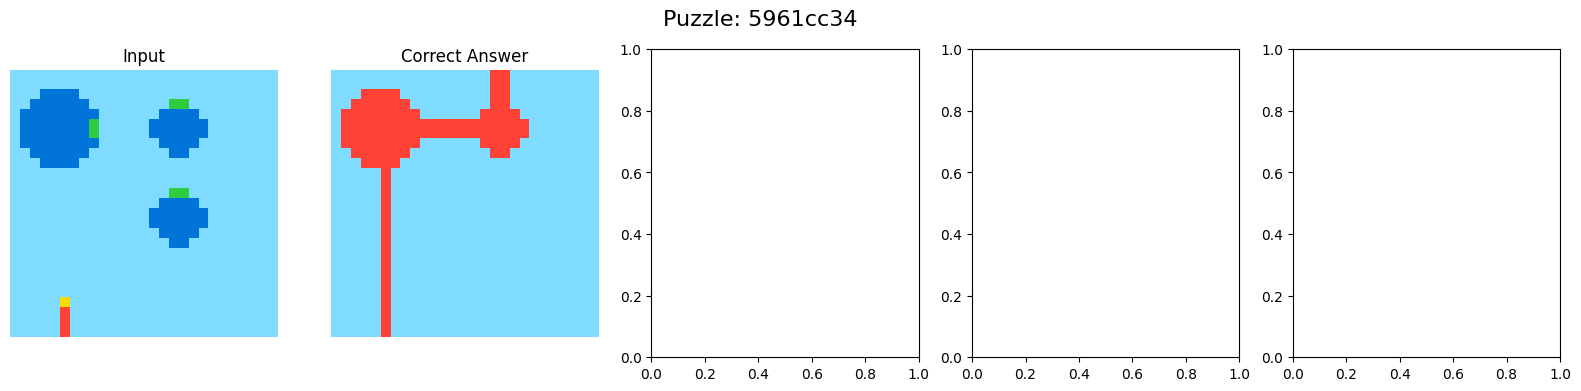

In [4]:
Ks=[1, 2, 10, 100, 1000]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
with open(os.path.join(os.path.dirname(CHECKPOINT_PATH), "all_config.yaml"), "r") as f:
    config = PretrainConfig(**yaml.safe_load(f))
config.data_paths, config.data_paths_test = [DATASET_PATH], [DATASET_PATH]
save_outputs = ["inputs", "labels", "puzzle_identifiers", "logits", "q_halt_logits"]
print("Starting evaluation")
_, eval_metadata = create_dataloader(config, "test", test_set_mode=True, epochs_per_iter=1, global_batch_size=config.global_batch_size, rank=0, world_size=1)
eval_loader, _ = create_dataloader(config, "test", test_set_mode=True, epochs_per_iter=1, global_batch_size=config.global_batch_size, rank=0, world_size=1)
model, _, _ = create_model(config, eval_metadata, rank=0, world_size=1)
state_dict = torch.load(CHECKPOINT_PATH, map_location=device)
if any(key.startswith("_orig_mod.") for key in model.state_dict().keys()) and not any(key.startswith("_orig_mod.") for key in state_dict.keys()):
    state_dict = {"_orig_mod." + k: v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=False)

model.model.initial_carry = types.MethodType(patched_initial_carry, model.model)
model.model.forward = types.MethodType(patched_forward, model.model)
model.to(device)
model.eval()

all_outputs = {key: [] for key in save_outputs}
eval_loader.dataset._lazy_load_dataset()
total_examples = sum(len(d["inputs"]) for d in eval_loader.dataset._data.values())
total_batches = math.ceil(total_examples / config.global_batch_size)
with torch.inference_mode():
    with tqdm(total=total_batches, desc="Evaluating") as pbar:
        for set_name, batch, global_batch_size in eval_loader:
            if global_batch_size == 0: continue
            pbar.set_description(f"Evaluating (Set: {set_name})")
            batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
            carry = model.initial_carry(batch)
            while True:
                carry, loss, metrics, preds, all_finish = model(carry=carry, batch=batch, return_keys=set(save_outputs))
                if all_finish: break
            outputs = {**batch, **preds}
            for key in save_outputs:
                if key in outputs:
                    all_outputs[key].append(outputs[key].cpu())
            pbar.update(1)

all_preds = {key: torch.cat(all_outputs[key], dim=0) for key in save_outputs if all_outputs[key]}
with open(os.path.join(DATASET_PATH, "identifiers.json"), "r") as f:
    identifier_map = {i: v for i, v in enumerate(json.load(f))}
mask = all_preds["puzzle_identifiers"] != PAD_PUZZLE_IDENTIFIER
all_preds = {k: v[mask] for k, v in all_preds.items()}
global_hmap, puzzle_labels = {}, {}
for identifier, input_tensor, label_tensor in zip(all_preds["puzzle_identifiers"], all_preds["inputs"], all_preds["labels"]):
    name = identifier_map[identifier.item()]
    if "_" not in name:
        puzzle_labels.setdefault(name, {})
        # 이제 crop 함수가 올바른 규칙으로 작동하며, 0~9 범위의 값을 반환합니다.
        input_np = crop(input_tensor.numpy())
        label_np = crop(label_tensor.numpy())
        input_hash, label_hash = grid_hash(input_np), grid_hash(label_np)
        global_hmap[input_hash], global_hmap[label_hash] = input_np, label_np
        if input_hash not in puzzle_labels[name]:
            puzzle_labels[name][input_hash] = label_hash
print(f"Number of original puzzles found: {len(puzzle_labels)}")

preds = all_preds["logits"].argmax(-1)
pred_answers = {}
for identifier, input_tensor, pred_tensor, q_tensor in zip(all_preds["puzzle_identifiers"], all_preds["inputs"], preds, all_preds["q_halt_logits"].sigmoid()):
    name = identifier_map[identifier.item()]
    orig_name = name.split("_")[0]
    if orig_name not in puzzle_labels: continue
    # 평가할 때도 crop을 통해 동일한 전처리 적용
    input_np_raw = input_tensor.numpy()
    input_hash = grid_hash(inverse_aug(name, crop(input_np_raw)))
    if input_hash not in puzzle_labels[orig_name]: continue

    pred_np_raw = pred_tensor.numpy()
    pred_np_processed = inverse_aug(name, crop(pred_np_raw))
    pred_hash = grid_hash(pred_np_processed)
    global_hmap[pred_hash] = pred_np_processed

    pred_answers.setdefault(orig_name, {})
    pred_answers[orig_name].setdefault(input_hash, [])
    pred_answers[orig_name][input_hash].append((pred_hash, q_tensor.item()))

correct = [0] * len(Ks)

In [5]:
# Ks 변수가 혹시 초기화되었을 수 있으니 다시 정의
Ks=[1, 2, 10, 100, 1000]

# --- 정확도 계산 ---
correct = [0] * len(Ks)
for name, tests in puzzle_labels.items():
    num_test_correct = [0] * len(Ks)
    for input_hash, label_hash in tests.items():
        if name in pred_answers and input_hash in pred_answers[name]:
            p = pred_answers[name][input_hash]
            p_map = {}
            for h, q in p:
                p_map.setdefault(h, [])
                p_map[h].append(q) # 점수(q)들을 리스트로 저장

            # 득표수와 평균 점수 계산
            p_map_processed = {
                h: (len(scores), sum(scores) / len(scores))
                for h, scores in p_map.items()
            }

            # 득표수 우선, 점수 차선으로 정렬
            p_map_sorted = sorted(p_map_processed.items(), key=lambda kv: (kv[1][0], kv[1][1]), reverse=True)

            for i, k in enumerate(Ks):
                ok = any(h == label_hash for h, stats in p_map_sorted[:k])
                num_test_correct[i] += ok

    for i in range(len(Ks)):
        if len(tests) > 0 and num_test_correct[i] == len(tests):
            correct[i] += 1

if len(puzzle_labels) > 0:
    for i, k in enumerate(Ks):
        print(f"Top-{k} Accuracy: {correct[i] / len(puzzle_labels) * 100:.2f}%")

# --- 시각화 ---
for puzzle_name, tests in tqdm(puzzle_labels.items(), desc="Visualizing puzzles"):
    num_tests = len(tests)
    max_preds_to_show = min(Ks[-1], 3)
    fig, axes = plt.subplots(num_tests, 2 + max_preds_to_show, figsize=(4 * (2 + max_preds_to_show), num_tests * 4), squeeze=False)
    fig.suptitle(f"Puzzle: {puzzle_name}", fontsize=16)

    for i, (input_hash, label_hash) in enumerate(tests.items()):
        axes[i, 0].imshow(global_hmap[input_hash], cmap=ARC_COLOR_MAP, vmin=0, vmax=9)
        axes[i, 0].set_title("Input")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(global_hmap[label_hash], cmap=ARC_COLOR_MAP, vmin=0, vmax=9)
        axes[i, 1].set_title("Correct Answer")
        axes[i, 1].axis('off')

        p_map_sorted_for_viz = []
        if puzzle_name in pred_answers and input_hash in pred_answers[puzzle_name]:
            p = pred_answers[puzzle_name][input_hash]

            # (오류 수정) 시각화 루프에서도 p_map을 올바르게 다시 계산합니다.
            p_map = {}
            for h, q in p:
                p_map.setdefault(h, [])
                p_map[h].append(q)

            p_map_processed = {
                h: (len(scores), sum(scores) / len(scores))
                for h, scores in p_map.items()
            }
            p_map_sorted_for_viz = sorted(p_map_processed.items(), key=lambda kv: (kv[1][0], kv[1][1]), reverse=True)

            for j, (h, stats) in enumerate(p_map_sorted_for_viz[:max_preds_to_show]):
                pred_grid = global_hmap[h]
                axes[i, 2+j].imshow(pred_grid, cmap=ARC_COLOR_MAP, vmin=0, vmax=9)
                title = f"Pred #{j+1}\n(Votes: {stats[0]}, Score: {stats[1]:.2f})"
                if h == label_hash:
                    axes[i, 2+j].spines[:].set_color('green')
                    axes[i, 2+j].spines[:].set_linewidth(4)
                axes[i, 2+j].set_title(title)
                axes[i, 2+j].axis('off')

        for j in range(len(p_map_sorted_for_viz), max_preds_to_show):
            axes[i, 2+j].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Output hidden; open in https://colab.research.google.com to view.